In [1846]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (OrdinalEncoder, 
    StandardScaler, 
    KBinsDiscretizer, 
    QuantileTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.impute import KNNImputer 

from feature_engine.imputation import ArbitraryNumberImputer, MeanMedianImputer, CategoricalImputer  
from feature_engine.encoding import RareLabelEncoder, OneHotEncoder, MeanEncoder, CountFrequencyEncoder
from feature_engine.pipeline import Pipeline

In [1847]:
data = pd.read_csv('../houseprice.csv').drop('Id', axis=1)
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [1848]:
def compare_regression_models(models_metrics, figsize=(20, 10), title='Model Comparison', 
                             colors={'train': '#1f77b4', 'test': '#ff7f0e'}, 
                             metrics_to_show=['R2', 'MSE', 'RMSE', 'MAE'],
                             show_delta=True, save_path=None):
    """
    Visualizes regression model performance with enhanced formatting and error handling
    
    Parameters:
    models_metrics (list): List of model metrics dictionaries from capture_metrics()
    metrics_to_show (list): Which metrics to display (default: ['R2', 'MSE', 'RMSE', 'MAE'])
    """
    plt.figure(figsize=figsize)
    n_metrics = len(metrics_to_show)
    bar_width = 0.35
    index = np.arange(len(models_metrics))
    
    # Create subplots grid
    fig, axs = plt.subplots(1, n_metrics, figsize=figsize)
    if n_metrics == 1:  # Handle single metric case
        axs = [axs]
    
    for i, metric in enumerate(metrics_to_show):
        ax = axs[i]
        train_vals = []
        test_vals = []
        
        # Extract metrics while handling potential missing keys
        for model in models_metrics:
            train_vals.append(model['metrics']['train'].get(metric, np.nan))
            test_vals.append(model['metrics']['test'].get(metric, np.nan))
        
        # Sort models by test performance
        if metric == 'R2':
            sort_idx = np.argsort(test_vals)[::-1]  # Descending for R2
        else:
            sort_idx = np.argsort(test_vals)  # Ascending for errors
            
        sorted_names = [models_metrics[i]['name'] for i in sort_idx]
        sorted_train = np.array(train_vals)[sort_idx]
        sorted_test = np.array(test_vals)[sort_idx]
        
        # Plot bars
        bars_train = ax.barh(index + bar_width/2, sorted_train, bar_width,
                            color=colors['train'], label='Train')
        bars_test = ax.barh(index - bar_width/2, sorted_test, bar_width,
                           color=colors['test'], label='Test')
        
        # Annotations and formatting
        ax.set_yticks(index)
        ax.set_yticklabels(sorted_names)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        
        # Value annotations
        max_val = max(max(sorted_train), max(sorted_test)) * 1.1
        for j, (tr, ts) in enumerate(zip(sorted_train, sorted_test)):
            # Train value
            ax.text(tr * 1.01 if metric == 'R2' else tr + max_val * 0.01,
                    j + bar_width/2, f'{tr:.3f}' if metric == 'R2' else f'{tr:,.1f}',
                    va='center', color=colors['train'], fontsize=9)
            
            # Test value
            ax.text(ts * 1.01 if metric == 'R2' else ts + max_val * 0.01,
                    j - bar_width/2, f'{ts:.3f}' if metric == 'R2' else f'{ts:,.1f}',
                    va='center', color=colors['test'], fontsize=9)
            
            # Delta annotation
            if show_delta:
                delta = tr - ts if metric == 'R2' else ts - tr
                delta_text = f'Δ={delta:+.3f}' if metric == 'R2' else f'Δ={delta:+,.1f}'
                ax.text(max_val * 0.95 if metric == 'R2' else max_val * 0.9,
                        j, delta_text, ha='right', va='center',
                        fontsize=8, style='italic')

        # Axis formatting
        if metric == 'R2':
            ax.set_xlim(0, 1.1)
            ax.set_xlabel('Score (Higher → Better)')
        else:
            ax.set_xlim(0, max_val)
            ax.set_xlabel('Error (Lower → Better)')
            if max_val > 1e6:
                ax.ticklabel_format(axis='x', style='sci', scilimits=(6, 6))
        
        ax.grid(axis='x', alpha=0.3)
        ax.tick_params(axis='y', labelsize=9)
    
    # Add unified legend
    handles = [plt.Rectangle((0,0),1,1, color=colors['train']), 
              plt.Rectangle((0,0),1,1, color=colors['test'])]
    fig.legend(handles, ['Train', 'Test'], loc='upper center', 
              ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=10)
    
    plt.suptitle(title, y=1.1, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

In [1849]:
def capture_metrics(model_name, y_train, train_preds, y_test, test_preds, metrics_list):
    """
    Captures regression metrics and appends them to a list for later comparison
    
    Parameters:
    model_name (str): Name/identifier for the model
    y_train (array): True training values
    train_preds (array): Model predictions on training data
    y_test (array): True test values
    test_preds (array): Model predictions on test data
    metrics_list (list): List to store multiple models' metrics
    
    Returns:
    list: Updated metrics list with new model's metrics
    """
    # Calculate all metrics
    train_metrics = {
        'MSE': mean_squared_error(y_train, train_preds),
        'RMSE': np.sqrt(mean_squared_error(y_train, train_preds)),
        'MAE': mean_absolute_error(y_train, train_preds),
        'R2': r2_score(y_train, train_preds)
    }
    
    test_metrics = {
        'MSE': mean_squared_error(y_test, test_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_preds)),
        'MAE': mean_absolute_error(y_test, test_preds),
        'R2': r2_score(y_test, test_preds)
    }
    
    # Create structured entry
    model_entry = {
        'name': model_name,
        'metrics': {
            'train': train_metrics,
            'test': test_metrics
        }
    }
    
    # Add to metrics list
    metrics_list.append(model_entry)
    return metrics_list

In [1850]:
def print_and_capture_metrics(model_name, y_train, train_preds, y_test, test_preds, metrics_list):
    """Prints metrics in your original format while capturing them"""
    # Print metrics
    print(f'train mse: {mean_squared_error(y_train, train_preds)}')
    print(f'train rmse: {np.sqrt(mean_squared_error(y_train, train_preds))}')
    print(f'train r2: {r2_score(y_train, train_preds)}')
    print(f'train mae: {mean_absolute_error(y_train, train_preds)}\n')
    
    print(f'test mse: {mean_squared_error(y_test, test_preds)}')
    print(f'test rmse: {np.sqrt(mean_squared_error(y_test, test_preds))}')
    print(f'test r2: {r2_score(y_test, test_preds)}')
    print(f'test mae: {mean_absolute_error(y_test, test_preds)}\n')
    
    # Capture metrics
    return capture_metrics(model_name, y_train, train_preds, y_test, test_preds, metrics_list)

## Neighborhood changes to District 

In [1851]:
district_mapping = {
    # Northwest Suburbs (Established Family Zones)
    'NridgHt': 'Northwest Suburbs',
    'NoRidge': 'Northwest Suburbs',
    'StoneBr': 'Northwest Suburbs',
    'Somerst': 'Northwest Suburbs',
    
    # College District (Academic Community)
    'CollgCr': 'College District',
    'Gilbert': 'College District',
    'Veenker': 'College District',
    
    # Central Core (Historic/Urban Living)
    'OldTown': 'Central Core',
    'Edwards': 'Central Core',
    'IDOTRR': 'Central Core',
    
    # North Ames (Affordable Suburban)
    'Names': 'North Ames',
    'NWAmes': 'North Ames',
    'Blmngtn': 'North Ames',
    
    # Southwest (Transitional & Value Opportunities)
    'Mitchel': 'Southwest',
    'Sawyer': 'Southwest',
    'SawyerW': 'Southwest',
    'Crawfor': 'Southwest',
    
    # Eastside (Mixed-Use & First-Time Buyers)
    'BrkSide': 'Eastside',
    'MeadowV': 'Eastside',
    'BrDale': 'Eastside',
    
    # Greenbelt/Nature-Adjacent
    'ClearCr': 'Greenbelt/Nature-Adjacent',
    'Timber': 'Greenbelt/Nature-Adjacent',
    'Blueste': 'Greenbelt/Nature-Adjacent'
}

# Add the 'District' column to the DataFrame
data['District'] = data['Neighborhood'].map(district_mapping)

# Optional: Fill unmapped neighborhoods (e.g., 'SWISU') as 'Other'
data['District'] = data['District'].fillna('Other')

data = data.drop('Neighborhood', axis = 1)


In [1852]:
all_metrics = [] #dictionary to keep metrics of evaluated models

## Columns to sum up and drop

In [1853]:
def sum_and_drop_columns(df, columns_to_sum, new_col_name, drop_original=True):
   
    # Validate columns exist
    missing_cols = [col for col in columns_to_sum if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Columns not found in DataFrame: {missing_cols}")
    
    # Create new column with sum
    df[new_col_name] = df[columns_to_sum].sum(axis=1)
    
    # Remove original columns if requested
    if drop_original:
        df = df.drop(columns=columns_to_sum)
    
    return df

In [1854]:
data = sum_and_drop_columns(
    df=data,
    columns_to_sum=['WoodDeckSF', 'EnclosedPorch' ,'OpenPorchSF', '3SsnPorch', 'ScreenPorch'],
    new_col_name='TotalPorchSF',
    drop_original=True
)

In [1855]:
data = sum_and_drop_columns(
    df=data,
    columns_to_sum=['BsmtFinSF1', 'BsmtFinSF2'],
    new_col_name='TotBsmtFinSF',
    drop_original=True
)

## Columns to drop based on analysis

In [1856]:
data = data.drop(columns=[
    '2ndFlrSF', # was dropped because variable it equals to 'GrLivArea' - '1stFlrSF'
    'BsmtUnfSF', # was dropped because it equals to 'TotalBsmtSF' - 'TotalBsmtFinSF'
    'BsmtFinType1', # 1,2 were dropped because they show the level of finishing
    'BsmtFinType2', # instead we consider only square of Finished basement.
    'GarageCars', # highly correlated with GarageArea
    'GarageYrBlt', # highly correlated with YrBuilt
    'TotRmsAbvGrd', # highly correlated with GrLivArea
    'SaleCondition', # highly correlated with SaleType
    'Exterior2nd', # highly correlated with Exterior1st
    'Fireplaces', # highly correlated with FireplaceQu
    'MSSubClass', # correlation is close to 0 with target
    'OverallCond', # correlation is close to 0 with target
    'MoSold', # this and below variables correlation is below 0.2 with target
    'YrSold', 
    'MSSubClass',
    'LandContour',
    'LotConfig',
    'LandSlope',
    'Condition1',
    'BldgType',
    'ExterCond',
    'Street', # 99.59 %  of values contain Pave
    'Utilities', #99.93 % of values contain AllPub
    'Alley', #93.7 % of values contain 0.0
    'Condition2', # 98.97 % of values contain Norm
    'RoofMatl', # 98.22 %  of values contain CompShg
    'LowQualFinSF', # 98.22 % of values contain 0.0
    'BsmtHalfBath', # 94.38 % of values contain 0.0
    'KitchenAbvGr', # 95.34 % of values contain 1.0
    'Functional', # 93.15 % of values contain Typ
    'PoolArea', # 99.52 % of values contain 0.0
    'PoolQC', # 99.52 % of values contain 0.0
    'MiscFeature', #90.74 % of values contain Shed
    'MiscVal', # 96.44 % of values contain 0.0
    'PavedDrive', # 91.78 % of values contain Y
    'Heating', # 97.81 % of values contain GasA
    'CentralAir', # 93.49 % of values contain Y
    'Electrical', # 91.43 % of values contain SBrkr
    'BsmtCond', # 92.12 % of values contain TA
    'GarageQual', # 95.07 % of values contain TA
    'GarageCond', # 96.15 % of values contain TA
    'Fence'] # 80.74 % of values contain 0.0    
    , axis=1)

In [1857]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['SalePrice'], axis = 1),
    data['SalePrice'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((1022, 33), (438, 33))

In [1858]:
y_train_2d = y_train.values.reshape(-1, 1)

In [1859]:
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', subsample=5000)
qt.fit(y_train_2d)

QuantileTransformer(output_distribution='normal', subsample=5000)

In [1860]:
y_train_transformed = qt.transform(y_train_2d)

## Sorting Variables

In [1861]:
def find_columns_with_TA(df, case_sensitive=True):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    TA_columns = []
    
    for col in categorical_cols:
        # Convert to string and handle case
        unique_vals = df[col].dropna().astype(str).unique()
        
        if not case_sensitive:
            # Check case-insensitive match
            has_TA = any(val.upper() == 'TA' for val in unique_vals)
        else:
            # Check exact match
            has_TA = 'TA' in unique_vals
        
        if has_TA:
            TA_columns.append(col)
    
    return TA_columns

In [1862]:
numerical = data.select_dtypes(include=[np.number])

categorical = [var for var in X_train.columns if X_train[var].dtype == 'O']

temporal = [var for var in numerical if 'Yr' in var or 'Year' in var]

discrete = [var for var in X_train.columns if X_train[var].dtype != 'O'
           and X_train[var].nunique() < 20 and var not in temporal]

continuous = [var for var in X_train.columns if X_train[var].dtype != 'O' 
              and var not in discrete and var not in temporal]

cat_ordinal = find_columns_with_TA(X_train)

cat_nominal = [var for var in X_train.columns if X_train[var].dtype == 'O'
               and var not in cat_ordinal]

In [1863]:
data[continuous].isna().sum()

LotFrontage     259
LotArea           0
MasVnrArea        8
TotalBsmtSF       0
1stFlrSF          0
GrLivArea         0
GarageArea        0
TotalPorchSF      0
TotBsmtFinSF      0
dtype: int64

In [1864]:
global_order = ['Missing', 'Rare', 'Gd', 'TA', 'Ex'] #for ordinal encoding

In [1865]:
categories = [global_order for _ in cat_ordinal]#for ordinal encoding

In [1866]:
cont_pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5, weights='uniform')),
    ('transformer', QuantileTransformer(output_distribution='normal', 
                                        n_quantiles=800,
                                        random_state=0)),
    ('discretiser', KBinsDiscretizer(n_bins=5, strategy='quantile', encode='ordinal'))
])

In [1867]:
data[continuous].isna().sum()

LotFrontage     259
LotArea           0
MasVnrArea        8
TotalBsmtSF       0
1stFlrSF          0
GrLivArea         0
GarageArea        0
TotalPorchSF      0
TotBsmtFinSF      0
dtype: int64

In [1868]:
disc_pipe = Pipeline(steps=[
    ('imputer', ArbitraryNumberImputer(arbitrary_number=0)),
    ('transformer', QuantileTransformer(output_distribution='uniform',
                                       n_quantiles=800,
                                       random_state=0))
])

In [1869]:
data[discrete].isna().sum()

OverallQual     0
BsmtFullBath    0
FullBath        0
HalfBath        0
BedroomAbvGr    0
dtype: int64

In [1870]:
temp_pipe = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='median')),
    ('discretiser', KBinsDiscretizer(n_bins=8, strategy='quantile', encode='ordinal'))
])

In [1871]:
data[temporal].isna().sum()

YearBuilt       0
YearRemodAdd    0
dtype: int64

In [1872]:
cat_ord_pipe = Pipeline(steps=[
    ('imputer', CategoricalImputer(imputation_method='missing',
                                  fill_value = 'None')),
    ('rare_encoder', RareLabelEncoder(tol = 0.05,
                                n_categories=1,
                                replace_with='Rare',
                                missing_values='raise')),
    ('ord_encoder', OrdinalEncoder(categories=categories,
                                  handle_unknown='use_encoded_value',
                                  unknown_value=-1))
])

In [1873]:
data[cat_ordinal].isna().sum()

ExterQual        0
BsmtQual        37
HeatingQC        0
KitchenQual      0
FireplaceQu    690
dtype: int64

In [1874]:
cat_nom_pipe = Pipeline(steps=[
    ('imputer', CategoricalImputer(imputation_method='missing',
                                  fill_value='None')),
    ('rare_nom_encoder', RareLabelEncoder(tol = 0.05,
                                         n_categories=1,
                                         replace_with='Rare',
                                         missing_values='raise')),
    ('mean_encoder', MeanEncoder(smoothing='auto'))
])

In [1875]:
data[cat_nominal].isna().sum()

MSZoning          0
LotShape          0
HouseStyle        0
RoofStyle         0
Exterior1st       0
MasVnrType      872
Foundation        0
BsmtExposure     38
GarageType       81
GarageFinish     81
SaleType          0
District          0
dtype: int64

In [1876]:
preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', cont_pipe, continuous),
        ('discrete', disc_pipe, discrete),
        ('temporal', temp_pipe, temporal),
        ('ordinal', cat_ord_pipe, cat_ordinal),
        ('nominal', cat_nom_pipe, cat_nominal)
    ]
).set_output(transform='pandas')

In [1877]:
Lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Lasso())
])

In [1878]:
Lasso_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('scaler', StandardScaler()), ('regressor', Lasso())])

In [1879]:
X_train_preds_transformed = Lasso_pipe.predict(X_train)
X_test_preds_transformed = Lasso_pipe.predict(X_test)

In [1880]:
all_metrics = print_and_capture_metrics(
    model_name='Lasso',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 6409052526.751793
train rmse: 80056.55829944098
train r2: -0.05070634087043957
train mae: 55132.9659360226

test mse: 7138807815.596873
test rmse: 84491.46593353008
test r2: -0.05152700186409076
test mae: 56468.60544889291



# KNN Regressor

In [1881]:
KNN_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

In [1882]:
KNN_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('scaler', StandardScaler()),
                ('regressor', KNeighborsRegressor())])

In [1883]:
X_train_preds_transformed = KNN_pipe.predict(X_train)
X_test_preds_transformed = KNN_pipe.predict(X_test)

In [1884]:
all_metrics = print_and_capture_metrics(
    model_name='KNN',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 830377929.0249532
train rmse: 28816.27888928328
train r2: 0.8638670300011458
train mae: 17595.467273419556

test mse: 1125964373.253513
test rmse: 33555.39261062986
test r2: 0.8341485059975586
test mae: 20197.355017825357



# SVR Regressor

In [1885]:
SVR_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', SVR())
])

In [1886]:
SVR_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                  Pipeline(steps=[('imputer',
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('scaler', StandardScaler()), ('regressor', SVR())])

In [1887]:
X_train_preds_transformed = SVR_pipe.predict(X_train)
X_test_preds_transformed = SVR_pipe.predict(X_test)

In [1888]:
all_metrics = print_and_capture_metrics(
    model_name='SVR',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 339482143.2156031
train rmse: 18425.041199834617
train r2: 0.9443449653439336
train mae: 9931.890666600846

test mse: 1117998667.5268946
test rmse: 33436.487069171824
test r2: 0.8353218328158185
test mae: 18827.041400429767



# Decision Tree Regressor

In [1889]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('SalePrice', axis=1),
    data['SalePrice'],
    test_size=0.3,
    random_state=0
)
X_train.shape, X_test.shape

((1022, 33), (438, 33))

In [1890]:
DT_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor())
])

In [1891]:
DT_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('scaler', StandardScaler()),
                ('regressor', DecisionTreeRegressor())])

In [1892]:
X_train_preds_transformed = DT_pipe.predict(X_train)
X_test_preds_transformed = DT_pipe.predict(X_test)

In [1893]:
all_metrics = print_and_capture_metrics(
    model_name='Desicion_Tree',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 127561.43506077565
train rmse: 357.1574373588987
train r2: 0.9999790874535496
train mae: 29.06300184325302

test mse: 1954920004.2597644
test rmse: 44214.47731523878
test r2: 0.7120455930369469
test mae: 27408.886156486893



# Random Forest Regressor

In [1894]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [1895]:
rf_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                  Pipeline(steps=[('imputer',
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('regressor', RandomForestRegressor())])

In [1896]:
X_train_preds_transformed = rf_pipe.predict(X_train)
X_test_preds_transformed = rf_pipe.predict(X_test)

In [1897]:
all_metrics = print_and_capture_metrics(
    model_name='Random_Forest',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 118852599.53420489
train rmse: 10901.953931942882
train r2: 0.9805151885651943
train mae: 6930.897133291708

test mse: 820753321.7518038
test rmse: 28648.79267529094
test r2: 0.87910526491467
test mae: 17816.981681309404



# AdaBoost Regressor

In [1898]:
ada_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor())
])

In [1899]:
ada_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                  Pipeline(steps=[('imputer',
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('regressor', AdaBoostRegressor())])

In [1900]:
X_train_preds_transformed = ada_pipe.predict(X_train)
X_test_preds_transformed = ada_pipe.predict(X_test)

In [1901]:
all_metrics = print_and_capture_metrics(
    model_name='AdaBoost',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 1056908289.5484954
train rmse: 32510.125954054613
train r2: 0.8267294210943293
train mae: 22218.555541317488

test mse: 1362009876.2424266
test rmse: 36905.41797951118
test r2: 0.7993796445191549
test mae: 23857.797779368007



# Gradient Boosting Regressor

In [1902]:
gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=0))
])

In [1903]:
gb_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('regressor', GradientBoostingRegressor(random_state=0))])

In [1904]:
X_train_preds_transformed = gb_pipe.predict(X_train)
X_test_preds_transformed = gb_pipe.predict(X_test)

In [1905]:
all_metrics = print_and_capture_metrics(
    model_name='GradientBoost',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 322959109.000852
train rmse: 17971.06310157671
train r2: 0.9470537677367042
train mae: 12456.880386691908

test mse: 649346867.5346963
test rmse: 25482.285367185894
test r2: 0.9043529700720051
test mae: 16394.062461138983



# XGBoost Regressor

In [1906]:
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor())
])

In [1907]:
xgb_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [1908]:
X_train_preds_transformed = xgb_pipe.predict(X_train)
X_test_preds_transformed = xgb_pipe.predict(X_test)

In [1909]:
all_metrics = print_and_capture_metrics(
    model_name='XGBoost',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 2613915.75
train rmse: 1616.760882134399
train r2: 0.9995714426040649
train mae: 948.3810424804688

test mse: 890971712.0
test rmse: 29849.14926760895
test r2: 0.8687622547149658
test mae: 18080.47265625



# LGBM Regressor

In [1910]:
lgbm_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor())
])

In [1911]:
lgbm_pipe.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 175
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 33
[LightGBM] [Info] Start training from score -0.000097


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                  Pipeline(steps=[('imputer',
                                                                   CategoricalImputer(fill_value='None')),
                                                                  ('rare_nom_encoder',
                                                                   RareLabelEncoder(n_categories=1)),
                                                                  ('mean_encoder',
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('regressor', LGBMRegressor())])

In [1912]:
X_train_preds_transformed = lgbm_pipe.predict(X_train)
X_test_preds_transformed = lgbm_pipe.predict(X_test)

In [1913]:
all_metrics = print_and_capture_metrics(
    model_name='LGBoost',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 140208727.50266945
train rmse: 11840.97662790825
train r2: 0.9770140440544816
train mae: 7383.139362203545

test mse: 761972499.9735613
test rmse: 27603.849368766692
test r2: 0.8877635203108358
test mae: 17349.611752837744



# Models Metrics Evaluation Report

In [1914]:
# gb_grid.fit(X_train, y_train_transformed)

In [1915]:
#gb_grid.best_params_

In [1916]:
gb_pipe_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(alpha=0.9,
                                           learning_rate=0.1,
                                           loss='huber',
                                           max_depth=4,
                                           max_features='log2',
                                           min_samples_leaf=4,
                                           min_samples_split=10,
                                           n_estimators=200,
                                           subsample=1.0,
                                           random_state=0))
])

In [1917]:
gb_pipe_grid.fit(X_train, y_train_transformed)

C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\home\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('transformer',
                                                                   QuantileTransformer(n_quantiles=800,
                                                                                       output_distribution='normal',
                                                                                       random_state=0)),
                                                                  ('discretiser',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'TotalBsmtSF',
                                                   '1stFlrSF', 'GrLivArea',
                                                   'Garag...
                                                                   MeanEncoder(smoothing='auto'))]),
                                                  ['MSZoning', 'LotShape',
                                                   'HouseStyle', 'RoofStyle',
                                                   'Exterior1st', 'MasVnrType',
                                                   'Foundation', 'BsmtExposure',
                                                   'GarageType', 'GarageFinish',
                                                   'SaleType', 'District'])])),
                ('regressor',
                 GradientBoostingRegressor(loss='huber', max_depth=4,
                                           max_features='log2',
                                           min_samples_leaf=4,
                                           min_samples_split=10,
                                           n_estimators=200, random_state=0))])

In [1918]:
X_train_preds_transformed = gb_pipe_grid.predict(X_train)
X_test_preds_transformed = gb_pipe_grid.predict(X_test)

In [1919]:
all_metrics = print_and_capture_metrics(
    model_name='Gradient_Boost_grid',
    y_train=y_train,
    train_preds=qt.inverse_transform(X_train_preds_transformed.reshape(-1,1)),
    y_test=y_test,
    test_preds=qt.inverse_transform(X_test_preds_transformed.reshape(-1,1)),
    #test_preds=X_test_preds,
    metrics_list=all_metrics
)

train mse: 232706967.8727129
train rmse: 15254.735916190517
train r2: 0.9618497920421144
train mae: 9151.345953453905

test mse: 737193584.7083795
test rmse: 27151.309079091923
test r2: 0.8914133872285744
test mae: 16322.685529026558



<Figure size 1500x600 with 0 Axes>

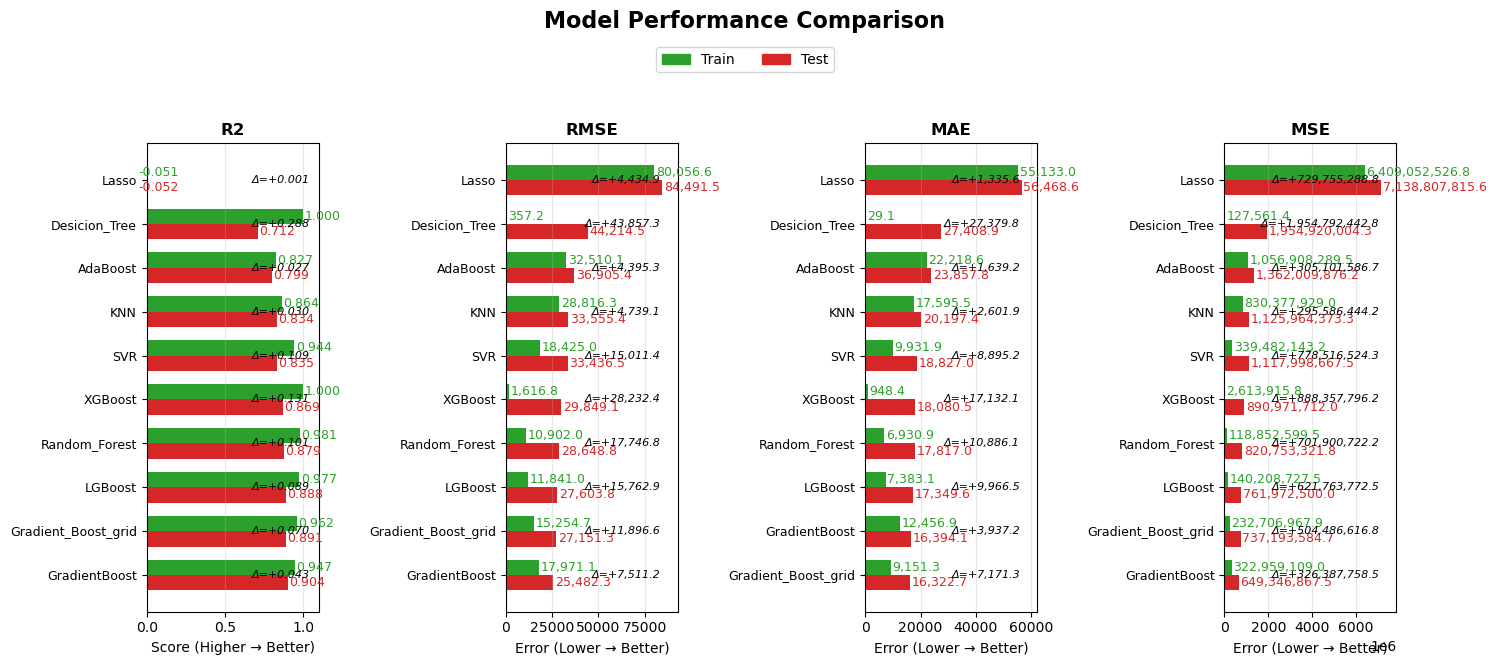

In [1920]:
compare_regression_models(
    all_metrics,
    metrics_to_show=['R2', 'RMSE', 'MAE', 'MSE'],  # Only show these metrics
    colors={'train': '#2ca02c', 'test': '#d62728'},
    title='Model Performance Comparison',
    figsize=(15, 6)
)